In [4]:
import os
os.chdir('../')
%pwd

'c:\\Users\\akish\\Bank_Marketing_Prediction_MLOps'

In [6]:
# %pip install mlflow hyperopt

In [8]:
import os
import io
import logging
import warnings
# from google.cloud import storage
import json
from datetime import datetime
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from hyperopt.pyll import scope
import pickle 
import numpy as np

In [11]:


# Logging Declarations
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

__file__ = "C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/src/model_development_pipeline.py"
PROJECT_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
DATA_DIR = os.path.join(PROJECT_DIR, "final_model")

# Hyperparameter search space for faster execution
SPACE = {
    'n_estimators': scope.int(hp.quniform('n_estimators', 50, 150, 50)),
    'max_depth': scope.int(hp.quniform('max_depth', 5, 15, 5)),
    'min_samples_split': scope.int(hp.quniform('min_samples_split', 2, 6, 2)),
    'min_samples_leaf': scope.int(hp.quniform('min_samples_leaf', 1, 3, 1)),
    'max_features': hp.choice('max_features', ['sqrt', 'log2']),
    'bootstrap': hp.choice('bootstrap', [True, False])
}

def log_metrics_to_file(metrics, model_name):
    log_dir = os.path.join(PROJECT_DIR, "logs")
    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, "ml_metrics.log")
    
    log_entry = {
        "timestamp": datetime.now().isoformat(),
        "model_name": model_name,
        **metrics
    }
    
    with open(log_file, "a") as f:
        f.write(json.dumps(log_entry) + "\n")

def setup_mlflow():
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("random_forest_classification")
    
KEY_PATH = os.path.join(PROJECT_DIR, "config", "key.json")
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = KEY_PATH
bucket_name = "mlopsprojectdatabucketgrp6"

def load_data(train_blob_path, test_blob_path):
    """Load train and test data from GCS bucket."""
    try:
        # Initialize Google Cloud Storage client
        # storage_client = storage.Client()
        # bucket = storage_client.bucket(bucket_name)
        
        # # Load train data from GCS
        # train_blob = bucket.blob(train_blob_path)
        # if not train_blob.exists():
        #     logger.error(f"Train file {train_blob_path} not found in bucket {bucket_name}")
        #     return None
        # train_data = pd.read_csv(io.BytesIO(train_blob.download_as_string()))
        # logger.info(f"Loaded train data from {train_blob_path} with shape {train_data.shape}")

        # # Load test data from GCS
        # test_blob = bucket.blob(test_blob_path)
        # if not test_blob.exists():
        #     logger.error(f"Test file {test_blob_path} not found in bucket {bucket_name}")
        #     return None
        # test_data = pd.read_csv(io.BytesIO(test_blob.download_as_string()))
        # logger.info(f"Loaded test data from {test_blob_path} with shape {test_data.shape}")

        __file__ = "C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/src/model_development_pipeline.py"
        PAR_DIRECTORY = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
        TRAIN_PATH = os.path.join(PAR_DIRECTORY, "data", "processed", "smote_resampled_train_data.csv")
        TEST_PATH = os.path.join(PAR_DIRECTORY, "data", "processed", "test_data.csv")
        #loading the train and test data form the local
        train_data = pd.read_csv(TRAIN_PATH)
        print("------train path------------",train_blob_path)
        logger.info(f"Loaded train data from {TRAIN_PATH} with shape {train_data.shape}")

        test_data = pd.read_csv(TEST_PATH)
        print("------test path------------",test_blob_path)
        logger.info(f"Loaded train data from {TEST_PATH} with shape {test_data.shape}")
        # Separate features and target
        X_train = train_data.drop('y', axis=1)
        y_train = train_data['y']
        X_test = test_data.drop('y', axis=1)
        y_test = test_data['y']
        
        return X_train, y_train, X_test, y_test
    except Exception as e:
        logger.exception(f"Error loading data from local: {e}")
        raise

def objective(params, X, y):
    """Objective function for hyperopt to minimize"""
    clf = RandomForestClassifier(**params, n_jobs=-1)
    score = cross_val_score(clf, X, y, cv=3, scoring='accuracy', n_jobs=-1).mean()
    return {'loss': -score, 'status': STATUS_OK}

def save_model_and_results(model, results, run_name, X_test, y_test):
    """Save the model and results as JSON in the models folder and return the JSON path."""
    DATA_DIR = os.path.join(PROJECT_DIR, "final_model")
    models_dir = DATA_DIR
    os.makedirs(models_dir, exist_ok=True)
    
    # Save model
    model_path = os.path.join(models_dir,f"random_forest_{run_name}.pkl")
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    
    # Save X_test and y_test to CSV
    X_test_path = os.path.join(models_dir,f"random_forest_{run_name}_X_test.csv")
    y_test_path = os.path.join(models_dir,f"random_forest_{run_name}_y_test.csv")
    X_test.to_csv(X_test_path, index=False)
    y_test.to_csv(y_test_path, index=False)

    # Convert int64 to regular int for JSON serialization
    def convert_to_serializable(obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        return obj

    # Save results
    results['timestamp'] = run_name
    results['model_path'] = str(model_path)
    results['X_test_path'] = str(X_test_path)
    results['y_test_path'] = str(y_test_path)
    serializable_results = json.loads(json.dumps(results, default=convert_to_serializable))
    results_path = os.path.join(models_dir, f"results_{run_name}.json")
    with open(results_path, 'w') as f:
        json.dump(serializable_results, f, indent=4)
    
    logger.info(f"Model saved to {model_path}")
    logger.info(f"X_test saved to {X_test_path}")
    logger.info(f"y_test saved to {y_test_path}")
    logger.info(f"Results saved to {results_path}")
    
    return results_path  # Return the path of the JSON file

def evaluate_model_performance(y_test, y_pred, threshold=0.7):
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }
    
    logger.info(f"Model performance metrics: {json.dumps(metrics)}")
    
    return all(metric >= threshold for metric in metrics.values()), metrics

def train_and_log_model(X_train, y_train, X_test, y_test):
    """Train multiple models and log results with MLflow"""
    run_name = datetime.now().strftime("%Y%m%d-%H%M%S")
    
    with mlflow.start_run(run_name=run_name) as parent_run:
        mlflow.set_tag("run_name", run_name)

        trials = Trials()
        
        # Perform hyperparameter optimization using Hyperopt
        best_params = fmin(fn=lambda params: objective(params, X_train, y_train), 
                           space=SPACE,
                           algo=tpe.suggest,
                           max_evals=10,
                           trials=trials)

        best_model = None
        best_performance = None
        best_metrics = None

        # Train and log each model from the trials
        for i in range(len(trials.trials)):
            trial = trials.trials[i]
            params = {
                'n_estimators': int(trial['misc']['vals']['n_estimators'][0]),
                'max_depth': int(trial['misc']['vals']['max_depth'][0]),
                'min_samples_split': int(trial['misc']['vals']['min_samples_split'][0]),
                'min_samples_leaf': int(trial['misc']['vals']['min_samples_leaf'][0]),
                'max_features': ['sqrt', 'log2'][trial['misc']['vals']['max_features'][0]],
                'bootstrap': [True, False][trial['misc']['vals']['bootstrap'][0]]
            }

            # Start a nested run for each model training
            with mlflow.start_run(run_name=f"{run_name}_model_{i}", nested=True) as child_run:
                # Train the model with current parameters
                model = RandomForestClassifier(**params)
                model.fit(X_train, y_train)

                # Evaluate on test set
                y_pred = model.predict(X_test)
                performance_ok, metrics = evaluate_model_performance(y_test, y_pred)

                # Log parameters and metrics for this model in MLflow directly without suffixes
                mlflow.log_params(params)
                mlflow.log_metrics(metrics)

                # Log the model to MLflow with a unique name based on trial index
                signature = infer_signature(X_test, y_pred)
                mlflow.sklearn.log_model(model, f"model_{i}", signature=signature)

                log_metrics_to_file(metrics, f"model_{i}")
                logger.info(f"Logged model {i} with parameters: {params}")

                # Update best model if this one performs better
                if best_model is None or metrics['accuracy'] > best_metrics['accuracy']:
                    best_model = model
                    best_performance = performance_ok
                    best_metrics = metrics

        # Save the best trained model and results locally after logging metrics
        log_metrics_to_file(best_metrics, "best_model")
        results = {
            **best_metrics,
            "best_params": best_params,
            "run_id": parent_run.info.run_id,
            "timestamp": run_name
        }
        logger.info("------model saving started----------")
        save_model_and_results(best_model, results, run_name, X_test, y_test)

        return best_performance, best_metrics

def run_model_development(train_path, test_path, max_attempts=3):
    setup_mlflow()
    X_train, y_train, X_test, y_test = load_data(train_path, test_path)
    attempt = 0
    while attempt < max_attempts:
        logger.info(f"Starting model development attempt {attempt + 1}")
        performance_ok, metrics = train_and_log_model(X_train, y_train, X_test, y_test)
        if performance_ok:
            logger.info("Model performance meets the threshold. Process complete.")
            log_metrics_to_file(metrics, f"final_model_attempt_{attempt + 1}")
            return metrics
        else:
            logger.warning("Model performance below threshold. Rerunning the process.")
            attempt += 1
    
    logger.error(f"Failed to achieve desired performance after {max_attempts} attempts.")
    log_metrics_to_file(metrics, f"final_model_attempt_{attempt}")
    return metrics

if __name__ == "__main__":
    # Example usage 
    __file__ = "C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/src/model_development_pipeline.py"
    PAR_DIRECTORY = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
    TRAIN_PATH = os.path.join(PAR_DIRECTORY, "data", "processed", "smote_resampled_train_data.csv")
    TEST_PATH = os.path.join(PAR_DIRECTORY, "data", "processed", "test_data.csv")
    final_metrics = run_model_development(TRAIN_PATH, TEST_PATH)
    print("Final model metrics:", final_metrics)

INFO:__main__:Loaded train data from C:\Users\akish\Bank_Marketing_Prediction_MLOps\data\processed\smote_resampled_train_data.csv with shape (63940, 16)
INFO:__main__:Loaded train data from C:\Users\akish\Bank_Marketing_Prediction_MLOps\data\processed\test_data.csv with shape (9043, 16)
INFO:__main__:Starting model development attempt 1


------train path------------ C:\Users\akish\Bank_Marketing_Prediction_MLOps\data\processed\smote_resampled_train_data.csv
------test path------------ C:\Users\akish\Bank_Marketing_Prediction_MLOps\data\processed\test_data.csv
  0%|          | 0/10 [00:00<?, ?trial/s, best loss=?]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.003015 seconds
INFO:hyperopt.tpe:TPE using 0 trials


 10%|█         | 1/10 [00:11<01:40, 11.16s/trial, best loss: -0.903722316600017]

INFO:hyperopt.tpe:build_posterior_wrapper took 0.000000 seconds
INFO:hyperopt.tpe:TPE using 1/1 trials with best loss -0.903722


...

🏃 View run 20250127-160153_model_8 at: http://127.0.0.1:5000/#/experiments/939563310002855987/runs/74cda6131c1644dcbc8b670a2c4e0b7a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/939563310002855987


INFO:__main__:Model performance metrics: {"accuracy": 0.8365586641601238, "precision": 0.8990533208381429, "recall": 0.8365586641601238, "f1_score": 0.8568979686386429}
INFO:__main__:Logged model 9 with parameters: {'n_estimators': 50, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}
INFO:__main__:------model saving started----------


🏃 View run 20250127-160153_model_9 at: http://127.0.0.1:5000/#/experiments/939563310002855987/runs/6a71bda006e34304973866630c47c423
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/939563310002855987


INFO:__main__:Model saved to C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\random_forest_20250127-160153.pkl
INFO:__main__:X_test saved to C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\random_forest_20250127-160153_X_test.csv
INFO:__main__:y_test saved to C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\random_forest_20250127-160153_y_test.csv
INFO:__main__:Results saved to C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\results_20250127-160153.json
INFO:__main__:Model performance meets the threshold. Process complete.


🏃 View run 20250127-160153 at: http://127.0.0.1:5000/#/experiments/939563310002855987/runs/4c426d10726848c1a0c2b7ed4466801f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/939563310002855987
Final model metrics: {'accuracy': 0.844741789229238, 'precision': 0.8992721821724214, 'recall': 0.844741789229238, 'f1_score': 0.862852787822957}


In [ ]:
# mlflow server --host localhost --port 5000
# mlflow server lunch

In [7]:
import os
import json
import logging
import pickle
import mlflow
import mlflow.sklearn

# Logging setup
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Define the directory where models and results are stored
__file__ = "C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/src/Model_Pipeline/compare_best_models.py"
PROJECT_DIR = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
DATA_DIR = os.path.join(PROJECT_DIR, "final_model")

def setup_mlflow():
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("random_forest_classification")

def load_metrics(file_path):
    """Load model metrics from a JSON file."""
    try:
        with open(file_path, 'r') as f:
            metrics = json.load(f)
        logger.info(f"Loaded metrics from {file_path}")
        return metrics
    except Exception as e:
        logger.error(f"Failed to load metrics from {file_path}: {e}")
        return None

def get_all_model_metrics():
    """Retrieve all model metrics files in DATA_DIR."""
    metrics_files = [f for f in os.listdir(DATA_DIR) if f.startswith("results_") and f.endswith(".json")]
    if not metrics_files:
        logger.warning("No model metrics files found in DATA_DIR.")
    else:
        logger.info(f"Found {len(metrics_files)} metrics files in DATA_DIR.")
    return [os.path.join(DATA_DIR, f) for f in metrics_files]

def simplify_metrics(metrics):
    """Flatten nested dictionary metrics to make them JSON-serializable."""
    simplified_metrics = {}
    for key, value in metrics.items():
        if isinstance(value, dict):
            for sub_key, sub_value in value.items():
                simplified_metrics[f"{key}_{sub_key}"] = sub_value  # Flatten nested dict
        else:
            simplified_metrics[key] = value
    return simplified_metrics

def log_best_model_in_mlflow(best_model_path, best_metrics):
    """Log and register the best model and its metrics in MLflow."""
    with mlflow.start_run(run_name="Best_Model_Logging"):
        # Log only numeric metrics
        for metric_name, metric_value in best_metrics.items():
            if isinstance(metric_value, (int, float)):
                mlflow.log_metric(metric_name, metric_value)
            else:
                logger.warning(f"Skipping non-numeric metric {metric_name}: {metric_value}")

        # Log and register the model
        with open(best_model_path, 'rb') as model_file:
            model = pickle.load(model_file)
            mlflow.sklearn.log_model(
                sk_model=model,
                artifact_path="best_model"
            )
            
            # Register the model
            model_name = "best_random_forest_model"
            mlflow.register_model(f"runs:/{mlflow.active_run().info.run_id}/best_model", model_name)
            
            # Transition the model to the "Staging" stage
            client = mlflow.tracking.MlflowClient()
            latest_version = client.get_latest_versions(model_name, stages=["None"])[0].version
            client.transition_model_version_stage(
                name=model_name,
                version=latest_version,
                stage="Staging"
            )
        
        logger.info(f"Logged and registered the best model '{model_name}' in MLflow and transitioned to 'Staging' stage.")

def get_test_file_paths(best_model_path):
    """
    Identify and return the paths for X_test and y_test files
    based on the best model path.

    Parameters:
    best_model_path (str): Path to the best model file
    """
    test_file_name = os.path.basename(best_model_path).replace(".pkl", "")
    X_test_path = os.path.join(DATA_DIR, f"{test_file_name}_X_test.csv")
    y_test_path = os.path.join(DATA_DIR, f"{test_file_name}_y_test.csv")

    logger.info(f"Identified X_test path: {X_test_path}")
    logger.info(f"Identified y_test path: {y_test_path}")

    return X_test_path, y_test_path

def compare_and_select_best():
    """Compare models from different sessions and update the best model if necessary."""
    all_metrics_files = get_all_model_metrics()
    if not all_metrics_files:
        logger.error("No metrics files available for comparison. Exiting.")
        return

    best_metrics = None
    best_model_path = None

    # Loop through each model's results file and compare metrics
    for metrics_file in all_metrics_files:
        metrics = load_metrics(metrics_file)
        if metrics is None:
            logger.warning(f"Skipping {metrics_file} due to loading issues.")
            continue

        # Update best model if this model's accuracy is higher
        if best_metrics is None or metrics['accuracy'] > best_metrics['accuracy']:
            best_metrics = metrics
            model_file = metrics_file.replace("results_", "random_forest_").replace(".json", ".pkl")
            best_model_path = os.path.join(DATA_DIR, model_file)
            logger.info(f"New best model found with accuracy {metrics['accuracy']} from {metrics_file}")

    # Load previously saved best model metrics, if any
    best_metrics_path = os.path.join(DATA_DIR, "best_model.json")
    if os.path.exists(best_metrics_path):
        previous_best_metrics = load_metrics(best_metrics_path)
        if previous_best_metrics and previous_best_metrics.get('accuracy', 0) >= best_metrics['accuracy']:
            logger.info("Previous best model still performs better. No update made.")
            # Call get_test_file_paths to get X_test and y_test paths
            X_test_path, y_test_path = get_test_file_paths(best_model_path)
            logger.info(f'Compare and select best-- X_test_path: {X_test_path}')
            logger.info(f'y_test_path: {y_test_path}')
            return best_model_path, X_test_path, y_test_path    # Return the path to the previous best model
        else:
            logger.info("Previous best model is being replaced by a new model.")

    # Update the best model and metrics if a new best model is found
    try:
        # Simplify metrics to ensure they are JSON-serializable
        flattened_metrics = simplify_metrics(best_metrics)
        
        # Save metrics to JSON
        with open(best_metrics_path, 'w') as f:
            json.dump(flattened_metrics, f, indent=4)
        logger.info(f"Saved new best model metrics to {best_metrics_path}")

        # Save the model file as the best model
        best_model_file = os.path.join(DATA_DIR, "best_model.pkl")
        with open(best_model_path, 'rb') as src, open(best_model_file, 'wb') as dest:
            dest.write(src.read())
        logger.info(f"Saved new best model file to {best_model_file}")

        # Log best model and metrics in MLflow
        log_best_model_in_mlflow(best_model_file, flattened_metrics)
        
        # Call get_test_file_paths to get X_test and y_test paths
        X_test_path, y_test_path = get_test_file_paths(best_model_path)

        logger.info(f'Compare and select best-- X_test_path: {X_test_path}')
        logger.info(f'y_test_path: {y_test_path}')

         # Return the path to the new best model file
        return best_model_file, X_test_path, y_test_path

    except Exception as e:
        logger.error(f"Failed to save the best model or metrics: {e}")

if __name__ == "__main__":
    logger.info("Starting model comparison and selection process.")
    setup_mlflow()
    compare_and_select_best()
    logger.info("Model comparison and selection process complete.")

INFO:__main__:Starting model comparison and selection process.
INFO:__main__:Found 2 metrics files in DATA_DIR.
INFO:__main__:Loaded metrics from C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\results_20250124-224437.json
INFO:__main__:New best model found with accuracy 0.8446312064580338 from C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\results_20250124-224437.json
INFO:__main__:Loaded metrics from C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\results_20250127-160153.json
INFO:__main__:New best model found with accuracy 0.844741789229238 from C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\results_20250127-160153.json
INFO:__main__:Loaded metrics from C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\best_model.json
INFO:__main__:Previous best model still performs better. No update made.
INFO:__main__:Identified X_test path: C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\random_forest_

INFO:__main__:Starting Sensitivity analysis
INFO:__main__:Best Model Path: C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/final_model/best_model.pkl


INFO:__main__:Loaded model from C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/final_model/best_model.pkl
INFO:__main__:Model:  RandomForestClassifier(bootstrap=False, max_depth=15, min_samples_leaf=2,
                       n_estimators=50)
INFO:__main__:Loading X from C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/final_model/random_forest_20250127-160153_X_test.csv
INFO:__main__:Loading y from C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/final_model/random_forest_20250127-160153_y_test.csv
INFO:__main__:Model for Feature Sensitivity Analysis: RandomForestClassifier(bootstrap=False, max_depth=15, min_samples_leaf=2,
                       n_estimators=50)
INFO:__main__:Feature: age, Importance: -0.0018, Standard Deviation: 0.0007
INFO:__main__:Feature: job, Importance: 0.0012, Standard Deviation: 0.0011
INFO:__main__:Feature: marital, Importance: 0.0009, Standard Deviation: 0.0011
INFO:__main__:Feature: education, Importance: 0.0015, Standard Deviation: 0.0010
INFO:_

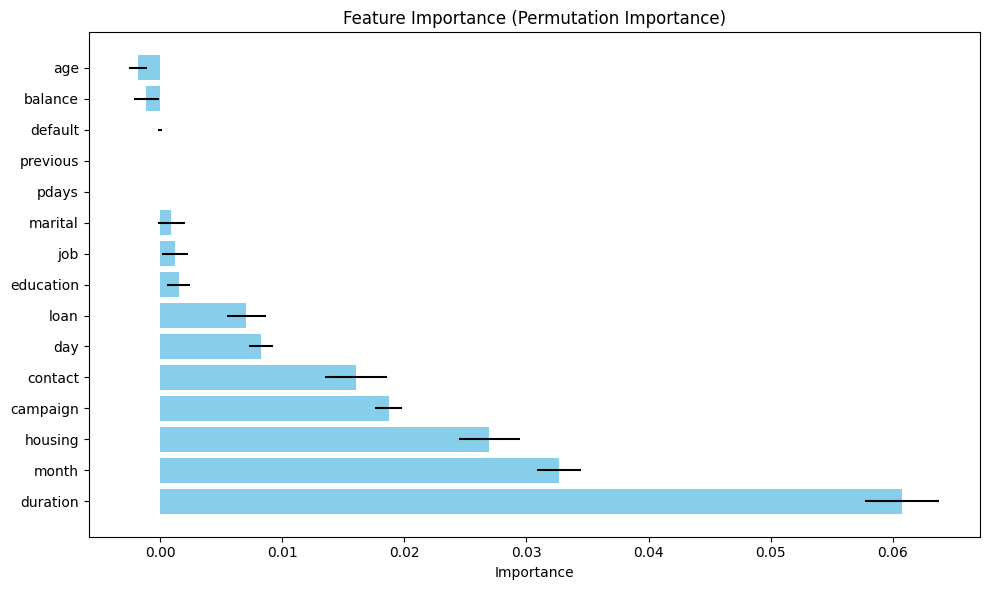

INFO:__main__:Feature sensitivity plot saved to C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\src\bias_analysis_output\feature_sensitivity.png
INFO:__main__:Model for Hyper-Parameter Sensitivity Analysis: RandomForestClassifier(bootstrap=False, max_depth=15, min_samples_leaf=2,
                       n_estimators=50)
INFO:__main__:Hyperparameters for Sensitivity Analysis: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
INFO:__main__:Analyzing parameter: max_depth (original value: 15)
INFO:__main__:Parameter: max_depth, Value: 7, Accuracy: 0.8892
INFO:__main__:Parameter: max_depth, Value: 11, Accuracy: 0.9557
INFO:__main__:Parameter: max_depth, Value: 15, Accuracy: 0.9912
INFO:__main__:Parameter: max_depth, Value: 18, Accuracy: 0.9991
INFO:__main__:Parameter: max_depth, Value: 22, Accuracy: 0.9998
INFO:__main__:Analyzing parameter: min_samples_leaf (original value: 2)
INFO:__main__:Parameter: min_samples_leaf, Value: 1, Accuracy: 1.0000
INFO:__

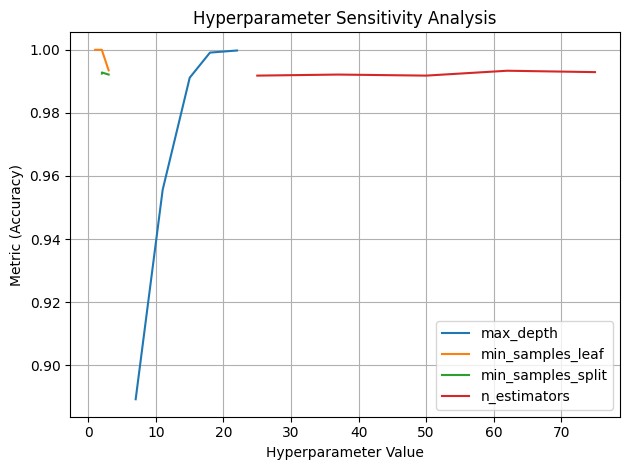

INFO:__main__:Hyperparameter sensitivity plot saved to C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\src\bias_analysis_output\hyperparameter_sensitivity.png
INFO:__main__:Completed Sensitivity analysis
INFO:__main__:Completed Sensitivity analysis


In [9]:
import os
import pickle
import pandas as pd
import json
import logging
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

# Logging Declarations
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")
__file__="C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/src/Model_Pipeline/sensitivity_analysis.py"
PROJECT_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
OUTPUT_DIR = os.path.join(PROJECT_DIR, "bias_analysis_output")
os.makedirs(OUTPUT_DIR, exist_ok=True) # Create the directory if it doesn't exist

def perform_sensitivity_analysis(model_path, X_path, y_path):
    """
    Perform sensitivity analysis to understand how variations in features affect the model's predictions.
    
    Parameters:
    - model_path: The path to the trained model.
    - X_path: The feature matrix for the test data.
    - y_path: The target vector for the test data.
    """
    logger.info(f"Best Model Path: {model_path}")
    try:
        # Load the trained model
        with open(model_path, 'rb') as model_file:
            model = pickle.load(model_file)
        logger.info(f"Loaded model from {model_path}")

        logger.info(f"Model:  {model}")

        # Extract hyperparameters from the model metadata
        hyperparams = {key: value for key, value in model.get_params().items()}
        #logger.info(f"Loaded hyperparameters: {json.dumps(hyperparams, indent=4)}")

        logger.info(f"Loading X from {X_path}")
        logger.info(f"Loading y from {y_path}")
        
        # Load test data
        X_data = pd.read_csv(X_path)
        y_data = pd.read_csv(y_path).squeeze()  # Use squeeze to get a Series if y is single-column

        # Ensure that 'y' (target column) is not present in X
        if 'y' in X_data.columns:
            X_data = X_data.drop(columns=['y'])

        logger.info(f"Model for Feature Sensitivity Analysis: {model}")
        # Perform permutation importance to evaluate feature importance
        result = permutation_importance(model, X_data, y_data, n_repeats=10, random_state=42, n_jobs=-1)
        
        # Store feature importances and their corresponding scores
        feature_importances = result.importances_mean
        std_importances = result.importances_std
        features = X_data.columns
        
        # Log feature importance values
        for feature, importance, std in zip(features, feature_importances, std_importances):
            logger.info(f"Feature: {feature}, Importance: {importance:.4f}, Standard Deviation: {std:.4f}")
        
        # Create a DataFrame for better visualization of results
        importance_df = pd.DataFrame({
            'Feature': features,
            'Importance': feature_importances,
            'Std Dev': std_importances
        })

        # Sort features by importance
        importance_df = importance_df.sort_values(by='Importance', ascending=False)

        # Plot the feature importance
        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['Feature'], importance_df['Importance'], xerr=importance_df['Std Dev'], color='skyblue')
        plt.xlabel('Importance')
        plt.title('Feature Importance (Permutation Importance)')
        plt.tight_layout()
        plt.show()

        # Save the feature sensitivity plot
        feature_plot_path = os.path.join(OUTPUT_DIR, "feature_sensitivity.png")
        plt.savefig(feature_plot_path)
        plt.close()
        logger.info(f"Feature sensitivity plot saved to {feature_plot_path}")

        logger.info(f"Model for Hyper-Parameter Sensitivity Analysis: {model}")
        
        # Define the parameters to analyze and their current values
        hyperparams_to_analyze = {
            'max_depth': model.get_params().get('max_depth'),
            'min_samples_leaf': model.get_params().get('min_samples_leaf'),
            'min_samples_split': model.get_params().get('min_samples_split'),
            'n_estimators': model.get_params().get('n_estimators'),
        }

        logger.info(f"Hyperparameters for Sensitivity Analysis: {hyperparams_to_analyze}")

        # Storage for sensitivity analysis results
        hyperparam_sensitivity = {}

        for param, original_value in hyperparams_to_analyze.items():
            logger.info(f"Analyzing parameter: {param} (original value: {original_value})")

            # Generate variations around the original value (±50%)
            variations = np.linspace(original_value * 0.5, original_value * 1.5, num=5).astype(int)
            param_impact = []

            for value in variations:
                try:
                    # Temporarily update the parameter
                    temp_model = model.set_params(**{param: value})
                    temp_model.fit(X_data, y_data)  # Fit with updated parameter
                    
                    # Evaluate the model (using accuracy as an example metric)
                    y_pred = temp_model.predict(X_data)
                    score = accuracy_score(y_data, y_pred)
                    param_impact.append((value, score))
                    
                    logger.info(f"Parameter: {param}, Value: {value}, Accuracy: {score:.4f}")
                except Exception as e:
                    logger.error(f"Error analyzing {param} with value {value}: {e}")
            
            hyperparam_sensitivity[param] = param_impact

        logger.info("Hyper-Parameter Sensitivity Analysis Complete")
        logger.info(f"hyperparam_sensitivity: {hyperparam_sensitivity}")
        # Log summary results
        for param, impacts in hyperparam_sensitivity.items():
            logger.info(f"Sensitivity Results for {param}: {impacts}")

        # Plot hyperparameter sensitivity
        for param, results in hyperparam_sensitivity.items():
            variations, impacts = zip(*results)  # Unpack results into variations and impacts
            
            if len(variations) != len(impacts):
                logger.error(f"Mismatch in dimensions for {param}: Variations {len(variations)}, Impacts {len(impacts)}")
                continue  # Skip this parameter to avoid the plotting error

            try:
                plt.plot(variations, impacts, label=param)
            except ValueError as e:
                logger.error(f"Error plotting {param}: {e}")

        plt.xlabel("Hyperparameter Value")
        plt.ylabel("Metric (Accuracy)")
        plt.title("Hyperparameter Sensitivity Analysis")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Save the hyperparameter sensitivity plot
        hyperparam_plot_path = os.path.join(OUTPUT_DIR, "hyperparameter_sensitivity.png")
        plt.savefig(hyperparam_plot_path)
        plt.close()
        logger.info(f"Hyperparameter sensitivity plot saved to {hyperparam_plot_path}")
        

        logger.info("Completed Sensitivity analysis")
        return importance_df, hyperparam_sensitivity
    
    except Exception as e:
        logger.exception(f"Error during sensitivity analysis: {e}")
        return None
    
if __name__ == "__main__":
    logger.info("Starting Sensitivity analysis")
    model_path = "C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/final_model/best_model.pkl"
    X_path = "C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/final_model/random_forest_20250127-160153_X_test.csv"
    y_path = "C:/Users/akish/Bank_Marketing_Prediction_MLOps/dags/final_model/random_forest_20250127-160153_y_test.csv"
    importance_df, hyperparam_sensitivity = perform_sensitivity_analysis(model_path, X_path, y_path)

    logger.info("Completed Sensitivity analysis")

In [18]:
import os
import logging
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Logging setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Path configurations
PROJECT_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(os.path.dirname(PROJECT_DIR), "final_model")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "bias_analysis_output")

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_data(path, sample_size=None):
    """Load data from CSV file with optional sampling"""
    logger.info(f"Loading data from {path}")
    data = pd.read_csv(path)
    if sample_size and len(data) > sample_size:
        data = data.sample(n=sample_size, random_state=42)
    X = data.drop('y', axis=1)
    y = data['y']
    logger.info(f"Data loaded successfully. Shape: {X.shape}")
    return X, y

def slice_data(X, feature, n_bins=5):
    """Slice data based on a specific feature"""
    logger.info(f"Slicing data for feature: {feature}")
    if feature == 'age':
        bins = [-np.inf, 0.2, 0.4, 0.6, 0.8, np.inf]
        labels = ['18-30', '31-45', '46-60', '61-75', '75+']
        return pd.cut(X[feature], bins=bins, labels=labels)
    elif feature == 'marital':
        bins = [-np.inf, 0.33, 0.66, np.inf]
        labels = ['single', 'married', 'divorced']
        return pd.cut(X[feature], bins=bins, labels=labels)
    elif X[feature].dtype == 'object':
        return X[feature].unique()
    else:
        return pd.qcut(X[feature], q=n_bins, duplicates='drop')

def evaluate_slice(model, X, y, feature, slice_value):
    """Evaluate model performance on a specific slice"""
    if feature == 'age':
        if slice_value == '18-30':
            mask = X[feature] <= 0.2
        elif slice_value == '31-45':
            mask = (X[feature] > 0.2) & (X[feature] <= 0.4)
        elif slice_value == '46-60':
            mask = (X[feature] > 0.4) & (X[feature] <= 0.6)
        elif slice_value == '61-75':
            mask = (X[feature] > 0.6) & (X[feature] <= 0.8)
        else:  # 75+
            mask = X[feature] > 0.8
    elif feature == 'marital':
        if slice_value == 'single':
            mask = X[feature] <= 0.33
        elif slice_value == 'married':
            mask = (X[feature] > 0.33) & (X[feature] <= 0.66)
        else:  # divorced
            mask = X[feature] > 0.66
    elif isinstance(slice_value, pd.Interval):
        mask = X[feature].between(slice_value.left, slice_value.right, inclusive='both')
    else:
        mask = X[feature] == slice_value
    
    if mask.sum() == 0:
        logger.warning(f"No samples found for slice {slice_value} of feature {feature}")
        return {
            'slice': str(slice_value),
            'size': 0,
            'accuracy': None,
            'precision': None,
            'recall': None,
            'f1': None
        }
    
    X_slice = X[mask]
    y_slice = y[mask]
    y_pred = model.predict(X_slice)
    accuracy = accuracy_score(y_slice, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_slice, y_pred, average='weighted')
    
    result = {
        'slice': str(slice_value),
        'size': mask.sum(),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    return result

def detect_bias(model, X, y, sensitive_features):
    """Detect bias across sensitive features"""
    logger.info(f"Detecting bias for features: {sensitive_features}")
    bias_results = {}
    for feature in sensitive_features:
        logger.info(f"Analyzing feature: {feature}")
        slices = slice_data(X, feature)
        feature_results = []
        for slice_value in slices.categories if hasattr(slices, 'categories') else slices:
            result = evaluate_slice(model, X, y, feature, slice_value)
            if result['size'] > 0:  # Only add results for non-empty slices
                feature_results.append(result)
        if feature_results:  # Only add feature if it has any non-empty slices
            bias_results[feature] = feature_results
            logger.info(f"Bias detection complete for {feature}. Number of valid slices: {len(feature_results)}")
        else:
            logger.warning(f"No valid slices found for feature {feature}")
    return bias_results

def visualize_bias(bias_results, metric='accuracy', output_dir=OUTPUT_DIR):
    """Visualize bias across features and slices"""
    logger.info("Visualizing bias results")
    for feature, results in bias_results.items():
        plt.figure(figsize=(10, 6))
        sns.barplot(x=[r['slice'] for r in results], y=[r[metric] for r in results])
        plt.title(f'{metric.capitalize()} across {feature} slices')
        plt.xlabel(feature)
        plt.ylabel(metric.capitalize())
        plt.xticks(rotation=45)
        plt.tight_layout()
        output_path = os.path.join(output_dir, f'bias_{feature}_{metric}.png')
        plt.savefig(output_path)
        plt.close()
        logger.info(f"Visualization saved to {output_path}")

def run_bias_analysis(model_path, test_path, sensitive_features, sample_size=1000):
    """Run the entire bias analysis process"""
    logger.info("Starting bias analysis")
    
    # Load the trained model
    logger.info(f"Loading model from: {model_path}")
    try:
        with open(model_path, 'rb') as f:
            model = pickle.load(f)
        logger.info("Model loaded successfully")
    except FileNotFoundError:
        logger.error(f"Model file not found at {model_path}")
        raise
    except Exception as e:
        logger.error(f"Error loading model: {e}")
        raise

    # Load data
    X, y = load_data(test_path, sample_size)

    # Detect bias
    bias_results = detect_bias(model, X, y, sensitive_features)

    if not bias_results:
        logger.warning("No valid bias results found. Skipping visualization.")
        return {}

    # Visualize bias
    visualize_bias(bias_results)

    logger.info("Bias analysis completed")
    return bias_results

if __name__ == "__main__":
    logger.info("Starting bias analysis script")
    model_path = os.path.join(MODEL_DIR, "best_model.pkl")
    test_path = os.path.join(os.path.dirname(os.path.dirname(os.path.dirname(DATA_DIR))),"data" ,"processed", "test_data.csv")
    sensitive_features = ['age', 'marital']
    sample_size = 1000  # Adjust this value based on your needs

    bias_results = run_bias_analysis(model_path, test_path, sensitive_features, sample_size)
    logger.info("Bias analysis completed.")
    logger.info(f"Results saved in {OUTPUT_DIR}")

INFO:__main__:Starting bias analysis script
INFO:__main__:Starting bias analysis
INFO:__main__:Loading model from: C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\final_model\best_model.pkl
INFO:__main__:Model loaded successfully
INFO:__main__:Loading data from C:\Users\akish\Bank_Marketing_Prediction_MLOps\data\processed\test_data.csv
INFO:__main__:Data loaded successfully. Shape: (1000, 15)
INFO:__main__:Detecting bias for features: ['age', 'marital']
INFO:__main__:Analyzing feature: age
INFO:__main__:Slicing data for feature: age
INFO:__main__:Bias detection complete for age. Number of valid slices: 1000
INFO:__main__:Analyzing feature: marital
INFO:__main__:Slicing data for feature: marital
INFO:__main__:Bias detection complete for marital. Number of valid slices: 1000
INFO:__main__:Visualizing bias results
INFO:__main__:Visualization saved to C:\Users\akish\Bank_Marketing_Prediction_MLOps\dags\src\bias_analysis_output\bias_age_accuracy.png
INFO:__main__:Visualization saved to 

In [11]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fooddelivery 0.0.2 requires geopy, which is not installed.
fooddelivery 0.0.2 requires pymongo, which is not installed.
You should consider upgrading via the 'c:\Users\akish\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.
